# Лабораторна робота №2 - Лінійна фільтрація зображень

### Завдання
Написати програмну реалiзацiю алгоритму лiнiйної фiльтрацiї зображень згорткою. Навести результати роботи вашої програми для наступних фiльтрiв:

    1. Зсув зображення на 10 пiкселiв вправо та 20 вниз.
    2. Iнверсiя.
    3. Згладжування по Гауссу (розмiр фiльтра не менше 11х11).
    4. Розмиття "рух по дiагоналi"(розмiр фiльтра не менше 7х7).
    5. Пiдвищення рiзкостi.
    6. Фiльтр Собеля (напрямок не важливий)
    7. Фiльтр границi
    8. Який-небудь цiкавий фiльтр який ви вигадали самi, або якого не було на лекцiї.

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

## Зображення:

0 255


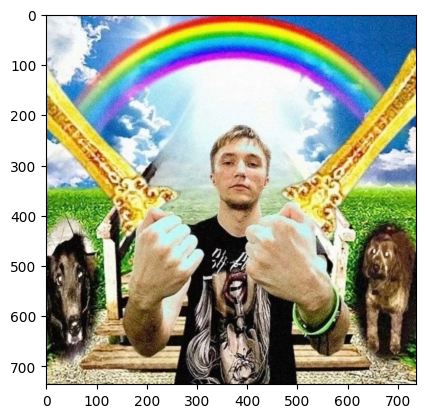

In [105]:
pic = plt.imread('serega.jpg')
plt.imshow(pic)
print(np.min(pic), np.max(pic))

In [95]:
def convolve(image, kernel):
    image = image.astype(np.float32)
    kernel = kernel.astype(np.float32)
    kh, kw = kernel.shape  #висота та ширина фільтрів, майже всі будуть 3 на 3, відповідно змінні нижче будуть 1 та 1
    ph, pw = kh // 2, kw // 2

    # Додаємо нулі навколо зображення
    padded = cv2.copyMakeBorder(image, ph, ph, pw, pw, cv2.BORDER_CONSTANT, value=0)

    # Підготовка вихідного зображення
    output = np.zeros_like(image)

    # Згортка
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            obl = padded[y:y+kh, x:x+kw] # для кожного пікселя зображення(без нульових границь) розглядаємо область(від поточних пікселів до ширини і висоти фільтра) на розширеній матриці
            output[y, x] = np.sum(obl * kernel)  # Тут очевидно, початкова матриця output, яка нульова протягом циклу присваює собі значення застосування фільтра до пікселів

    return output

In [87]:
def convolve_color(image, kernel): #Верхня функція згортки, але для всіх кольорових каналів
    output = np.zeros_like(image)
    for c in range(3):     # B, G, R
        output[:, :, c] = convolve(image[:, :, c], kernel)
    return output

## Зсув зображення на 10 пiкселiв вправо та 20 вниз.

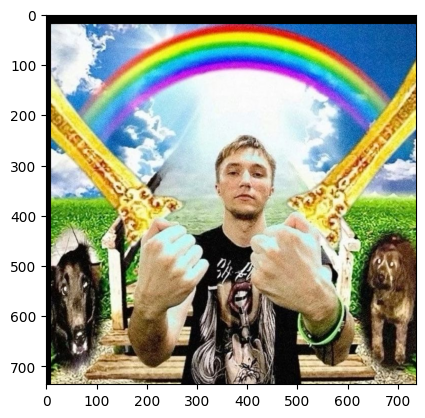

In [103]:
kernel = np.zeros((41, 41), dtype=np.float32)
kernel[0, 10] = 1

filtred = convolve_color(pic, kernel)
plt.imshow(filtred)

## Інверсія

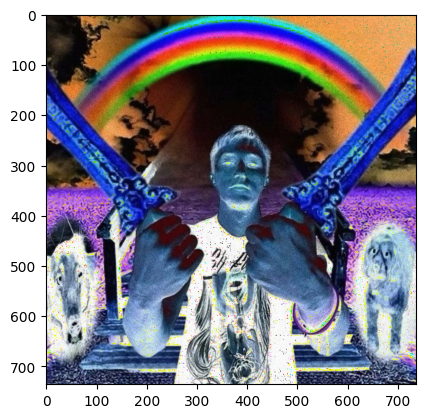

In [109]:
kernel = np.array([
    [0,  0,  0],
    [0,  -1, 0],
    [0,  0,  0]])

filtred = convolve_color(pic, kernel)
plt.imshow(filtred)

## Згладжування по Гауссу (розмiр фiльтра не менше 11х11)

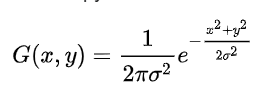

In [123]:
def GausMatriza(size, sigma):
    kernel = np.zeros((size, size))
    center = size // 2
        
    for y in range(size):
        for x in range(size):
            dx = x - center
            dy = y - center
            kernel[y, x] = 1/(2*math.pi * sigma**2 )*math.exp(-(dx**2 + dy**2) / (2 * sigma**2))
        
    return kernel

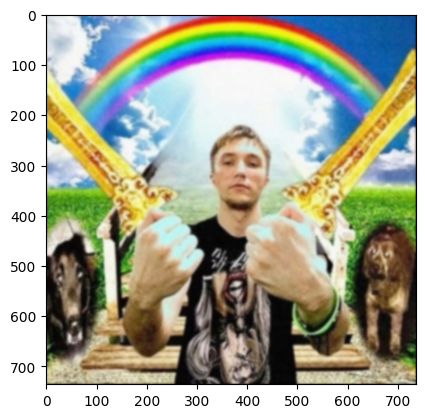

In [124]:
kernel = GausMatriza(11, 2)
#print(kernel)
filtred = convolve_color(pic, kernel)
plt.imshow(filtred)

## Розмиття "рух по дiагоналi"(розмiр фiльтра не менше 7х7)

ну, я думаю що це він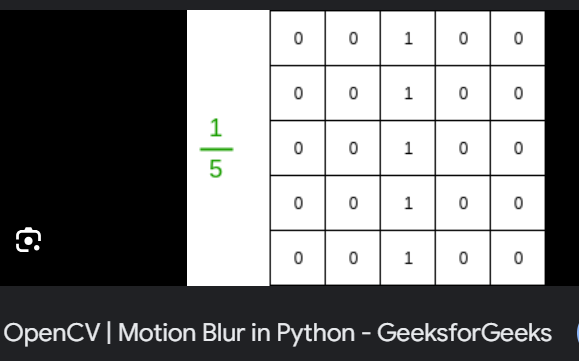

In [125]:
def MotionBlurMatrix(size):
    kernel = np.zeros((size, size))
    center = size // 2
        
    for x in range(size):
        kernel[size//2,x] = 1/size
        
    return kernel

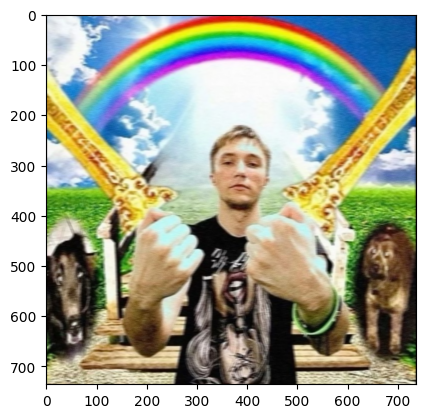

In [128]:
kernel = MotionBlurMatrix(7)
filtred = convolve_color(pic, kernel)
plt.imshow(filtred)

## Пiдвищення рiзкостi

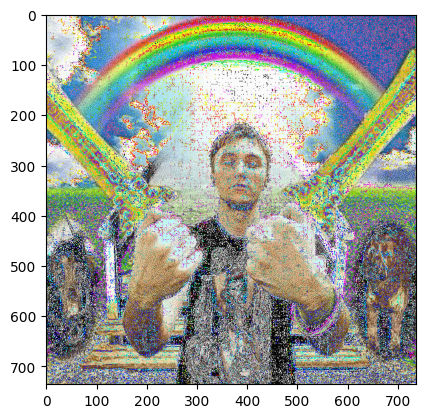

In [129]:
kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])
filtred = convolve_color(pic, kernel)
plt.imshow(filtred)


## Фiльтр Собеля 

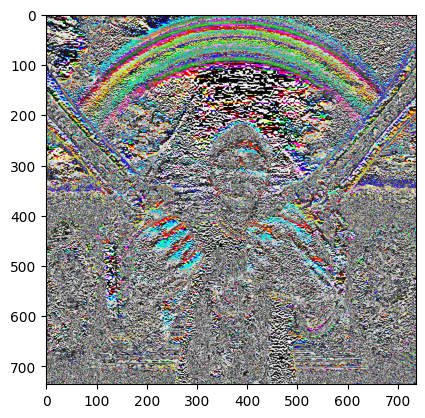

In [130]:
kernel = np.array([
            [-1, -2, -1],
            [0, 0, 0],
            [1, 2, 1]
        ])
filtred = convolve_color(pic, kernel)
plt.imshow(filtred)


## Фiльтр границi

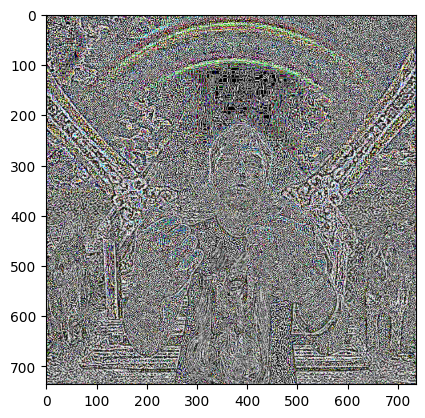

In [132]:
kernel = np.array([
            [0, 1, 0],
            [1, -4, 1],
            [0, 1, 0]
        ])
filtred = convolve_color(pic, kernel)
plt.imshow(filtred)


## Фільтр Волкобоя

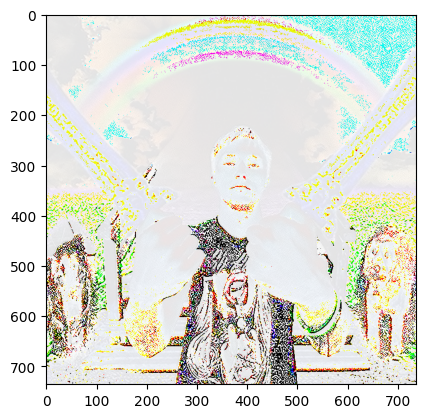

In [161]:
kernel = np.array([
            [-1/3, 1/9, 1/27],
            [1/9, -1/9, 1/27],
            [1/27, 1/27, -1/27]
        ])
filtred = convolve_color(pic, kernel)
plt.imshow(filtred)


In [166]:
def gamnomatrix(size, number):
    g = np.zeros((size,size))
    for y in range(size):
        for x in range(size):
            g[y, x] = 1/(number**(max(y,x)+1))
            if (x==y):
                g[y,x] = -g[y,x]
    return g

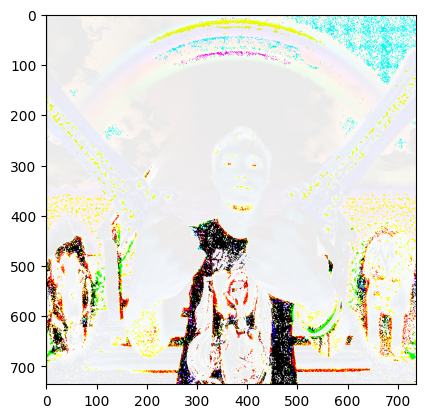

In [178]:
kernel = gamnomatrix(5,10)
#print(kernel)
filtred = convolve_color(pic, kernel)
plt.imshow(filtred)
